In [1]:
library(dplyr)
library(tidyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
hmCG <- read.csv("../output/05-5hmC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv", stringsAsFactors = FALSE,check.names = F)
head(hmCG);dim(hmCG)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Lamp5 Gaba_compartment,Pvalb Gaba_compartment,Sst Gaba_compartment,STR D1 Gaba_compartment,STR D2 Gaba_compartment,ACB-BST-FS D1 Gaba_compartment,Astro-TE NN_compartment,Oligo NN_compartment,OPC NN_compartment,Microglia NN_compartment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,


[1] 24639    62

In [ ]:
subclass_our_liu <- read.csv("../../../03.data/02.metainfo/01.Young_Mouse/subclass_name.Joint_Cabernet_corresponding_to_3C.csv")
head(subclass_our_liu);dim(subclass_our_liu)

,subclass_our,subclass_liu
,<chr>,<chr>
1,L2/3 IT CTX Glut,L2_3_IT_CTX_Glut
2,L4/5 IT CTX Glut,L4_5_IT_CTX_Glut
3,L5 IT CTX Glut,L5_IT_CTX_Glut
4,L6 IT CTX Glut,L6_IT_CTX_Glut
5,IT AON-TT-DP Glut,IT_AON-TT-DP_Glut
6,LA-BLA-BMA-PA Glut,LA-BLA-BMA-PA_Glut


[1] 30  2

In [ ]:
file_list <- list.files(path = "../analysis/m3C_seq/data/AB_compartment_score/", 
                        pattern = "\\.bw$", full.names = FALSE)
head(file_list);length(file_list)

[1] "ABC_NN.compartment_score.100K.bw"                    
[2] "ACB-BST-FS_D1_Gaba.compartment_score.100K.bw"        
[3] "AD_Serpinb7_Glut.compartment_score.100K.bw"          
[4] "ADP-MPO_Trp73_Glut.compartment_score.100K.bw"        
[5] "AHN_Onecut3_Gaba.compartment_score.100K.bw"          
[6] "AHN-RCH-LHA_Otp_Fezf1_Glut.compartment_score.100K.bw"

[1] 273

In [5]:
subclass_liu <- sub("\\.compartment_score\\.100K\\.bw$", "", file_list) %>% data.frame()
colnames(subclass_liu) <- "subclass_liu"
head(subclass_liu);dim(subclass_liu)

,subclass_liu
,<chr>
1,ABC_NN
2,ACB-BST-FS_D1_Gaba
3,AD_Serpinb7_Glut
4,ADP-MPO_Trp73_Glut
5,AHN_Onecut3_Gaba
6,AHN-RCH-LHA_Otp_Fezf1_Glut


[1] 273   1

In [6]:
table(subclass_our_liu$subclass_liu %in% subclass_liu$subclass_liu)


TRUE 
  30 

In [ ]:
subclass_liu_bw <- paste0("../analysis/m3C_seq/data/AB_compartment_score/",
                          subclass_our_liu$subclass_liu,".compartment_score.100K.bw")

subclass_liu_bw

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L2_3_IT_CTX_Glut.compartment_score.100K.bw"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L4_5_IT_CTX_Glut.compartment_score.100K.bw"     
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L5_IT_CTX_Glut.compartment_score.100K.bw"       
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L6_IT_CTX_Glut.compartment_score.100K.bw"       
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/IT_AON-TT-DP_Glut.compartment_score.100K.bw"    
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/LA-BLA-BMA-PA_Glut.compartment_score.100K.bw"   
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L2_3_IT_RSP_Glut.compartment_score.100K.bw"     
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L4_RSP-ACA_Glut.compartment_score.100K.bw"      
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L5_ET_CTX_Glut.compartment_score.100K.bw"       
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/SUB-ProS_Glut.compartment_score.100K.bw"        
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/CA1-ProS_Glut.compartment_score.100K.bw"        
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/CA3_Glut.compartment_score.100K.bw"             
[13] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/CLA-EPd-CTX_Car3_Glut.compartment_score.100K.bw"
[14] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L5_NP_CTX_Glut.compartment_score.100K.bw"       
[15] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/L6_CT_CTX_Glut.compartment_score.100K.bw"       
[16] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/DG_Glut.compartment_score.100K.bw"              
[17] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OB_Eomes_Ms4a15_Glut.compartment_score.100K.bw" 
[18] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OB-in_Frmd7_Gaba.compartment_score.100K.bw"     
[19] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/OB-out_Frmd7_Gaba.compartment_score.100K.bw"    
[20] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Sncg_Gaba.compartment_score.100K.bw"            
[21] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Lamp5_Gaba.compartment_score.100K.bw"           
[22] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Pvalb_Gaba.compartment_score.100K.bw"           
[23] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Sst_Gaba.compartment_score.100K.bw"             
[24] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/STR_D1_Gaba.compartment_score.100K.bw"          
[25] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/STR_D2_Gaba.compartment_score.100K.bw"          
[26] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/ACB-BST-FS_D1_Gaba.compartment_score.100K.bw"   
[27] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Astro-TE_NN.compartment_score.100K.bw"          
[28] "/share/analysisdata/Methyl/public/TSO/yangfa/analysis/m3C_seq/data/AB_compartment_score/Oligo_NN.compartment_score.100K.bw"           

In [8]:
library(rtracklayer)

Warning message:
“package ‘rtracklayer’ was built under R version 4.3.3”
Loading required package: GenomicRanges

Warning message:
“package ‘GenomicRanges’ was built under R version 4.3.3”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max

In [9]:
read_bw_to_df <- function(file) {
  data <- as.data.frame(import(file))
  data$subclass <- gsub(".compartment_score.100K.bw","",basename(file))
  return(data)
}

In [10]:
all_bw_data <- lapply(subclass_liu_bw, read_bw_to_df)

combined_df <- do.call(rbind, all_bw_data)

In [11]:
head(combined_df);dim(combined_df)

,seqnames,start,end,width,strand,score,subclass
,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<chr>
1,chr1,1,100000,100000,*,0,L2_3_IT_CTX_Glut
2,chr1,100001,200000,100000,*,0,L2_3_IT_CTX_Glut
3,chr1,200001,300000,100000,*,0,L2_3_IT_CTX_Glut
4,chr1,300001,400000,100000,*,0,L2_3_IT_CTX_Glut
5,chr1,400001,500000,100000,*,0,L2_3_IT_CTX_Glut
6,chr1,500001,600000,100000,*,0,L2_3_IT_CTX_Glut


[1] 790500      7

In [12]:
table(combined_df$subclass %in% subclass_our_liu$subclass_liu)


  TRUE 
790500 

In [13]:
combined_df$subclass <- subclass_our_liu$subclass_our[match(combined_df$subclass,subclass_our_liu$subclass_liu)]

In [14]:
head(combined_df);dim(combined_df)

,seqnames,start,end,width,strand,score,subclass
,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<chr>
1,chr1,1,100000,100000,*,0,L2/3 IT CTX Glut
2,chr1,100001,200000,100000,*,0,L2/3 IT CTX Glut
3,chr1,200001,300000,100000,*,0,L2/3 IT CTX Glut
4,chr1,300001,400000,100000,*,0,L2/3 IT CTX Glut
5,chr1,400001,500000,100000,*,0,L2/3 IT CTX Glut
6,chr1,500001,600000,100000,*,0,L2/3 IT CTX Glut


[1] 790500      7

In [15]:
combined_df <- combined_df %>%
  mutate(chrom100k = paste0(seqnames, "_", (start - 1) %/% 100000))

In [16]:
head(combined_df);dim(combined_df)

,seqnames,start,end,width,strand,score,subclass,chrom100k
,<fct>,<int>,<int>,<int>,<fct>,<dbl>,<chr>,<chr>
1,chr1,1,100000,100000,*,0,L2/3 IT CTX Glut,chr1_0
2,chr1,100001,200000,100000,*,0,L2/3 IT CTX Glut,chr1_1
3,chr1,200001,300000,100000,*,0,L2/3 IT CTX Glut,chr1_2
4,chr1,300001,400000,100000,*,0,L2/3 IT CTX Glut,chr1_3
5,chr1,400001,500000,100000,*,0,L2/3 IT CTX Glut,chr1_4
6,chr1,500001,600000,100000,*,0,L2/3 IT CTX Glut,chr1_5


[1] 790500      8

In [17]:
library(tidyr)

In [18]:
wide_df <- combined_df %>%
  select(chrom100k, score, subclass) %>%
  pivot_wider(
    names_from = subclass,
    values_from = score
  ) %>% data.frame(check.names = FALSE)

In [19]:
wide_df

chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1_0,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_1,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_2,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_3,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_4,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_5,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_6,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_7,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000
chr1_8,0.00000,0.00000,0.00000,0.0000,0.000000,0.00000,0.00000,0.000000,0.00000,⋯,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.00000,0.00000,0.00000


In [20]:
head(hmCG);dim(hmCG)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Lamp5 Gaba_compartment,Pvalb Gaba_compartment,Sst Gaba_compartment,STR D1 Gaba_compartment,STR D2 Gaba_compartment,ACB-BST-FS D1 Gaba_compartment,Astro-TE NN_compartment,Oligo NN_compartment,OPC NN_compartment,Microglia NN_compartment
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,,,,,,,,,,


[1] 24639    62

In [21]:
grep("compartment$",colnames(hmCG),value = T)

[1] "L2/3 IT CTX Glut_compartment"      "L4/5 IT CTX Glut_compartment"     
 [3] "L5 IT CTX Glut_compartment"        "L6 IT CTX Glut_compartment"       
 [5] "IT AON-TT-DP Glut_compartment"     "LA-BLA-BMA-PA Glut_compartment"   
 [7] "L2/3 IT RSP Glut_compartment"      "L4 RSP-ACA Glut_compartment"      
 [9] "L5 ET CTX Glut_compartment"        "SUB-ProS Glut_compartment"        
[11] "CA1-ProS Glut_compartment"         "CA3 Glut_compartment"             
[13] "CLA-EPd-CTX Car3 Glut_compartment" "L5 NP CTX Glut_compartment"       
[15] "L6 CT CTX Glut_compartment"        "DG Glut_compartment"              
[17] "OB Eomes Ms4a15 Glut_compartment"  "OB-in Frmd7 Gaba_compartment"     
[19] "OB-out Frmd7 Gaba_compartment"     "Sncg Gaba_compartment"            
[21] "Lamp5 Gaba_compartment"            "Pvalb Gaba_compartment"           
[23] "Sst Gaba_compartment"              "STR D1 Gaba_compartment"          
[25] "STR D2 Gaba_compartment"           "ACB-BST-FS D1 Gaba_compartment"   
[27] "Astro-TE NN_compartment"           "Oligo NN_compartment"             
[29] "OPC NN_compartment"                "Microglia NN_compartment"

In [22]:
hmCG <- hmCG %>% dplyr::select(-c(grep("compartment$",colnames(hmCG),value = T),"OEC NN"))

In [23]:
head(hmCG);dim(hmCG)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


[1] 24639    31

In [24]:
table(hmCG$chrom100k %in% wide_df$chrom100k)
table(wide_df$chrom100k %in% hmCG$chrom100k)


 TRUE 
24639 


FALSE  TRUE 
 1711 24639 

In [25]:
wide_df_filter <- wide_df[wide_df$chrom100k %in% hmCG$chrom100k,]

In [26]:
head(wide_df_filter);dim(wide_df_filter)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,chr1_1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,chr1_2,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,chr1_3,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,chr1_4,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,chr1_5,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


[1] 24639    31

In [27]:
hmCG <- hmCG[hmCG$chrom100k %in% wide_df$chrom100k,]
head(hmCG);dim(hmCG)

,chrom100k,L2/3 IT CTX Glut,L4/5 IT CTX Glut,L5 IT CTX Glut,L6 IT CTX Glut,IT AON-TT-DP Glut,LA-BLA-BMA-PA Glut,L2/3 IT RSP Glut,L4 RSP-ACA Glut,L5 ET CTX Glut,⋯,Lamp5 Gaba,Pvalb Gaba,Sst Gaba,STR D1 Gaba,STR D2 Gaba,ACB-BST-FS D1 Gaba,Astro-TE NN,Oligo NN,OPC NN,Microglia NN
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,chr1_1,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,chr1_2,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,chr1_3,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,chr1_4,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,chr1_5,NA,NA,NA,NA,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


[1] 24639    31

In [28]:
merged_df <- merge(wide_df_filter, hmCG, by = "chrom100k", suffixes = c("_3C", "_hmCG"))

In [29]:
head(merged_df);dim(merged_df)

,chrom100k,L2/3 IT CTX Glut_3C,L4/5 IT CTX Glut_3C,L5 IT CTX Glut_3C,L6 IT CTX Glut_3C,IT AON-TT-DP Glut_3C,LA-BLA-BMA-PA Glut_3C,L2/3 IT RSP Glut_3C,L4 RSP-ACA Glut_3C,L5 ET CTX Glut_3C,⋯,Lamp5 Gaba_hmCG,Pvalb Gaba_hmCG,Sst Gaba_hmCG,STR D1 Gaba_hmCG,STR D2 Gaba_hmCG,ACB-BST-FS D1 Gaba_hmCG,Astro-TE NN_hmCG,Oligo NN_hmCG,OPC NN_hmCG,Microglia NN_hmCG
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,chr1_0,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,chr1_1,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,chr1_10,0.000000,0.0000000,0.000000,0.000000,0.0000000,0.000000,0.0000000,0.0000000,0.000000,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,chr1_100,-3.553936,0.7758843,2.683697,-2.528243,0.6797727,-4.283804,-0.2897587,0.4430414,5.251019,⋯,0.2834850,0.3126369,0.3098496,0.2304022,0.1624046,0.2759126,0.15463164,0.13046195,0.06634180,0.04590859
5,chr1_1000,-19.238665,-19.4752712,-14.370521,-20.941557,-11.2771664,-8.810387,-19.2338257,-4.7738547,-6.669826,⋯,0.2620722,0.3460626,0.3012467,0.2763888,0.1732374,0.2916362,0.08172356,0.05890871,0.04286229,0.02766170
6,chr1_1001,-19.035269,-19.7375679,-14.601047,-20.930523,-11.6334047,-9.037502,-19.3711510,-4.7195754,-7.194997,⋯,0.2452355,0.3200099,0.2901749,0.2511972,0.1358427,0.2911570,0.05795081,0.04833313,0.04240240,0.01929142


[1] 24639    61

In [30]:
subclass_columns <- colnames(wide_df_filter)[-1]
subclass_columns

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "L6 IT CTX Glut"        "IT AON-TT-DP Glut"     "LA-BLA-BMA-PA Glut"   
 [7] "L2/3 IT RSP Glut"      "L4 RSP-ACA Glut"       "L5 ET CTX Glut"       
[10] "SUB-ProS Glut"         "CA1-ProS Glut"         "CA3 Glut"             
[13] "CLA-EPd-CTX Car3 Glut" "L5 NP CTX Glut"        "L6 CT CTX Glut"       
[16] "DG Glut"               "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"     
[19] "OB-out Frmd7 Gaba"     "Sncg Gaba"             "Lamp5 Gaba"           
[22] "Pvalb Gaba"            "Sst Gaba"              "STR D1 Gaba"          
[25] "STR D2 Gaba"           "ACB-BST-FS D1 Gaba"    "Astro-TE NN"          
[28] "Oligo NN"              "OPC NN"                "Microglia NN"

In [31]:
correlation_df <- data.frame(
  subclass = character(),
  correlation = numeric(),
  p_value = numeric(),
  stringsAsFactors = FALSE
)

In [32]:
for (i in seq_along(subclass_columns)) {
  subclass <- subclass_columns[i]
  wide_values <- merged_df[[paste0(subclass, "_3C")]]
  hmCG_values <- merged_df[[paste0(subclass, "_hmCG")]]

  test_result <- cor.test(wide_values, hmCG_values, method = "pearson", use = "complete.obs")

  correlation_df <- rbind(correlation_df, data.frame(
    subclass = subclass,
    correlation = test_result$estimate,
    p_value = test_result$p.value
  ))
}

In [33]:
correlation_df

,subclass,correlation,p_value
,<chr>,<dbl>,<dbl>
cor,L2/3 IT CTX Glut,0.2135773,5.744489e-246
cor1,L4/5 IT CTX Glut,0.2531789,0.000000e+00
cor2,L5 IT CTX Glut,0.2713751,0.000000e+00
cor3,L6 IT CTX Glut,0.2919840,0.000000e+00
cor4,IT AON-TT-DP Glut,0.2603694,0.000000e+00
cor5,LA-BLA-BMA-PA Glut,0.2316942,2.849956e-290
cor6,L2/3 IT RSP Glut,0.2526256,0.000000e+00
cor7,L4 RSP-ACA Glut,0.2120878,1.810483e-242
cor8,L5 ET CTX Glut,0.2255689,7.505285e-275


In [ ]:
calculate_correlation <- function(data_path) {

  read_and_fix <- function(file_path) {
    df <- read.csv(file_path, stringsAsFactors = FALSE, check.names = FALSE)
    if (colnames(df)[1] == "") {
      colnames(df)[1] <- "chrom100k"
      message("The first column name in the file '", file_path, "' was empty and has been replaced with 'chrom100k'.")
    }
    return(df)
  }

  data <- read_and_fix(data_path)
  print(dim(data))

  data <- data %>%
    dplyr::select(-c(grep("compartment$", colnames(data), value = TRUE), "OEC NN"))

  subclass_our_liu <- read.csv("../output/01-subclass_our_liu.csv")

  bw_dir <- "../analysis/m3C_seq/data/AB_compartment_score/"

  file_list <- list.files(path = bw_dir, pattern = "\\.bw$", full.names = FALSE)
  subclass_liu <- sub("\\.compartment_score\\.100K\\.bw$", "", file_list) %>% data.frame()
  colnames(subclass_liu) <- "subclass_liu"

  subclass_liu_bw <- paste0(bw_dir, "/", subclass_our_liu$subclass_liu, ".compartment_score.100K.bw")

  read_bw_to_df <- function(file) {
    data <- as.data.frame(import(file))
    data$subclass <- gsub(".compartment_score.100K.bw", "", basename(file))
    return(data)
  }

  all_bw_data <- lapply(subclass_liu_bw, read_bw_to_df)
  combined_df <- do.call(rbind, all_bw_data)

  combined_df$subclass <- subclass_our_liu$subclass_our[match(combined_df$subclass, subclass_our_liu$subclass_liu)]

  combined_df <- combined_df %>%
    mutate(chrom100k = paste0(seqnames, "_", (start - 1) %/% 100000))

  wide_df <- combined_df %>%
    select(chrom100k, score, subclass) %>%
    pivot_wider(
      names_from = subclass,
      values_from = score
    ) %>%
    data.frame(check.names = FALSE)

  print(table(data$chrom100k %in% wide_df$chrom100k))
  print(table(wide_df$chrom100k %in% data$chrom100k))

  wide_df_filter <- wide_df[wide_df$chrom100k %in% data$chrom100k, ]
  data <- data[data$chrom100k %in% wide_df$chrom100k, ]

  merged_df <- merge(wide_df_filter, data, by = "chrom100k", suffixes = c("_3C", "_data"))

  subclass_columns <- colnames(wide_df_filter)[-1]

  correlations <- numeric(length(subclass_columns))
  p_values <- numeric(length(subclass_columns))

  for (i in seq_along(subclass_columns)) {
    subclass <- subclass_columns[i]
    wide_values <- merged_df[[paste0(subclass, "_3C")]]
    data_values <- merged_df[[paste0(subclass, "_data")]]
    cor_test_result <- cor.test(wide_values, data_values, method = "pearson", use = "complete.obs")
    correlations[i] <- cor_test_result$estimate
    p_values[i] <- cor_test_result$p.value 
  }

  correlation_df <- data.frame(
  subclass = subclass_columns, 
  correlation = correlations,
  p_value = p_values)

  return(correlation_df)
}

In [35]:
cor_5hmCG <- calculate_correlation("../output/05-5hmC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv")
cor_5hmCG

[1] 24639    62

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


subclass,correlation,p_value
<chr>,<dbl>,<dbl>
L2/3 IT CTX Glut,0.2135773,5.744489e-246
L4/5 IT CTX Glut,0.2531789,0.000000e+00
L5 IT CTX Glut,0.2713751,0.000000e+00
L6 IT CTX Glut,0.2919840,0.000000e+00
IT AON-TT-DP Glut,0.2603694,0.000000e+00
LA-BLA-BMA-PA Glut,0.2316942,2.849956e-290
L2/3 IT RSP Glut,0.2526256,0.000000e+00
L4 RSP-ACA Glut,0.2120878,1.810483e-242
L5 ET CTX Glut,0.2255689,7.505285e-275


In [36]:
cor_5hmCG_5mCG <- calculate_correlation("../output/05-5mC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv")
cor_5hmCG_5mCG

[1] 24639    62

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


subclass,correlation,p_value
<chr>,<dbl>,<dbl>
L2/3 IT CTX Glut,-0.3825015,0.000000e+00
L4/5 IT CTX Glut,-0.3792472,0.000000e+00
L5 IT CTX Glut,-0.3911453,0.000000e+00
L6 IT CTX Glut,-0.3899526,0.000000e+00
IT AON-TT-DP Glut,-0.3761090,0.000000e+00
LA-BLA-BMA-PA Glut,-0.3198783,0.000000e+00
L2/3 IT RSP Glut,-0.4209616,0.000000e+00
L4 RSP-ACA Glut,-0.4072435,0.000000e+00
L5 ET CTX Glut,-0.3862967,0.000000e+00


In [37]:
cor_5mCG <- calculate_correlation("../output/05-true5mC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv")
cor_5mCG

The first column name in the file '../output/05-true5mC_CG_chrom100k_subclass_mean_dat_final_with_compartment.csv' was empty and has been replaced with 'chrom100k'.



[1] 24639    62

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


subclass,correlation,p_value
<chr>,<dbl>,<dbl>
L2/3 IT CTX Glut,-0.402045153,0.0000000
L4/5 IT CTX Glut,-0.417658202,0.0000000
L5 IT CTX Glut,-0.435982751,0.0000000
L6 IT CTX Glut,-0.444765420,0.0000000
IT AON-TT-DP Glut,-0.421149526,0.0000000
LA-BLA-BMA-PA Glut,-0.375746504,0.0000000
L2/3 IT RSP Glut,-0.452296540,0.0000000
L4 RSP-ACA Glut,-0.430227906,0.0000000
L5 ET CTX Glut,-0.410625291,0.0000000


In [38]:
cor_5hmCH <- calculate_correlation("../output/05-5hmC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv")
cor_5hmCH

[1] 24639    62

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


subclass,correlation,p_value
<chr>,<dbl>,<dbl>
L2/3 IT CTX Glut,0.20873835,8.518608e-235
L4/5 IT CTX Glut,0.22249055,2.801703e-267
L5 IT CTX Glut,0.24640460,0.000000e+00
L6 IT CTX Glut,0.15868660,2.724069e-135
IT AON-TT-DP Glut,0.17755616,2.063124e-169
LA-BLA-BMA-PA Glut,0.11439652,8.326462e-71
L2/3 IT RSP Glut,0.22011121,1.699007e-261
L4 RSP-ACA Glut,0.18498171,6.135302e-184
L5 ET CTX Glut,0.24140495,1.044991e-315


In [39]:
cor_5hmCH_5mCH <- calculate_correlation("../output/05-5mC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv")
cor_5hmCH_5mCH

[1] 24639    62

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


subclass,correlation,p_value
<chr>,<dbl>,<dbl>
L2/3 IT CTX Glut,0.006986552,2.787950e-01
L4/5 IT CTX Glut,0.070889765,3.705044e-28
L5 IT CTX Glut,0.027193740,2.484490e-05
L6 IT CTX Glut,0.016624116,9.963202e-03
IT AON-TT-DP Glut,0.007652117,2.355505e-01
LA-BLA-BMA-PA Glut,0.043900838,9.878203e-12
L2/3 IT RSP Glut,-0.014007426,2.989976e-02
L4 RSP-ACA Glut,-0.036798772,1.156356e-08
L5 ET CTX Glut,-0.044065898,8.256108e-12


In [40]:
cor_5mCH <- calculate_correlation("../output/05-true5mC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv")
cor_5mCH

The first column name in the file '../output/05-true5mC_CH_chrom100k_subclass_mean_dat_final_with_compartment.csv' was empty and has been replaced with 'chrom100k'.



[1] 24639    62

 TRUE 
24639 

FALSE  TRUE 
 1711 24639 


subclass,correlation,p_value
<chr>,<dbl>,<dbl>
L2/3 IT CTX Glut,-0.038330054,2.783214e-09
L4/5 IT CTX Glut,0.031553067,9.961297e-07
L5 IT CTX Glut,-0.019065283,3.119965e-03
L6 IT CTX Glut,-0.028864363,7.632748e-06
IT AON-TT-DP Glut,-0.036917588,1.036813e-08
LA-BLA-BMA-PA Glut,0.003065239,6.346887e-01
L2/3 IT RSP Glut,-0.056637008,1.543900e-18
L4 RSP-ACA Glut,-0.075226231,1.671339e-31
L5 ET CTX Glut,-0.083911366,8.239878e-39


In [41]:
library(ggplot2)

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


In [42]:
cor_5hmCG$Group <- "5hmCG"
cor_5hmCG_5mCG$Group <- "5hmCG+5mCG"
cor_5mCG$Group <- "5mCG"
cor_5hmCH$Group <- "5hmCH"
cor_5hmCH_5mCH$Group <- "5hmCH+5mCH"
cor_5mCH$Group <- "5mCH"

In [43]:
all_correlations <- bind_rows(cor_5hmCG, cor_5hmCG_5mCG, cor_5mCG, cor_5hmCH, cor_5hmCH_5mCH, cor_5mCH)

In [44]:
head(all_correlations);dim(all_correlations)

,subclass,correlation,p_value,Group
,<chr>,<dbl>,<dbl>,<chr>
1,L2/3 IT CTX Glut,0.2135773,5.744489e-246,5hmCG
2,L4/5 IT CTX Glut,0.2531789,0.000000e+00,5hmCG
3,L5 IT CTX Glut,0.2713751,0.000000e+00,5hmCG
4,L6 IT CTX Glut,0.2919840,0.000000e+00,5hmCG
5,IT AON-TT-DP Glut,0.2603694,0.000000e+00,5hmCG
6,LA-BLA-BMA-PA Glut,0.2316942,2.849956e-290,5hmCG


[1] 180   4

In [45]:
all_correlations

subclass,correlation,p_value,Group
<chr>,<dbl>,<dbl>,<chr>
L2/3 IT CTX Glut,0.2135773,5.744489e-246,5hmCG
L4/5 IT CTX Glut,0.2531789,0.000000e+00,5hmCG
L5 IT CTX Glut,0.2713751,0.000000e+00,5hmCG
L6 IT CTX Glut,0.2919840,0.000000e+00,5hmCG
IT AON-TT-DP Glut,0.2603694,0.000000e+00,5hmCG
LA-BLA-BMA-PA Glut,0.2316942,2.849956e-290,5hmCG
L2/3 IT RSP Glut,0.2526256,0.000000e+00,5hmCG
L4 RSP-ACA Glut,0.2120878,1.810483e-242,5hmCG
L5 ET CTX Glut,0.2255689,7.505285e-275,5hmCG


In [46]:
subclass_order <- c('L2/3 IT CTX Glut','L4/5 IT CTX Glut','L5 IT CTX Glut','L6 IT CTX Glut','IT AON-TT-DP Glut',
                                            'LA-BLA-BMA-PA Glut','L2/3 IT RSP Glut','L4 RSP-ACA Glut','L5 ET CTX Glut','SUB-ProS Glut',
                                            'CA1-ProS Glut','CA3 Glut','CLA-EPd-CTX Car3 Glut','L5 NP CTX Glut','L6 CT CTX Glut','DG Glut',
                                            'OB Eomes Ms4a15 Glut','OB-in Frmd7 Gaba','OB-out Frmd7 Gaba','Sncg Gaba','Lamp5 Gaba',
                                            'Pvalb Gaba','Sst Gaba','STR D1 Gaba','STR D2 Gaba','ACB-BST-FS D1 Gaba','Astro-TE NN',
                                            'Oligo NN','OPC NN','Microglia NN')

subclass_order

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "L6 IT CTX Glut"        "IT AON-TT-DP Glut"     "LA-BLA-BMA-PA Glut"   
 [7] "L2/3 IT RSP Glut"      "L4 RSP-ACA Glut"       "L5 ET CTX Glut"       
[10] "SUB-ProS Glut"         "CA1-ProS Glut"         "CA3 Glut"             
[13] "CLA-EPd-CTX Car3 Glut" "L5 NP CTX Glut"        "L6 CT CTX Glut"       
[16] "DG Glut"               "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"     
[19] "OB-out Frmd7 Gaba"     "Sncg Gaba"             "Lamp5 Gaba"           
[22] "Pvalb Gaba"            "Sst Gaba"              "STR D1 Gaba"          
[25] "STR D2 Gaba"           "ACB-BST-FS D1 Gaba"    "Astro-TE NN"          
[28] "Oligo NN"              "OPC NN"                "Microglia NN"

In [47]:
all_correlations$subclass <- factor(all_correlations$subclass,levels = subclass_order)

levels(all_correlations$subclass)

[1] "L2/3 IT CTX Glut"      "L4/5 IT CTX Glut"      "L5 IT CTX Glut"       
 [4] "L6 IT CTX Glut"        "IT AON-TT-DP Glut"     "LA-BLA-BMA-PA Glut"   
 [7] "L2/3 IT RSP Glut"      "L4 RSP-ACA Glut"       "L5 ET CTX Glut"       
[10] "SUB-ProS Glut"         "CA1-ProS Glut"         "CA3 Glut"             
[13] "CLA-EPd-CTX Car3 Glut" "L5 NP CTX Glut"        "L6 CT CTX Glut"       
[16] "DG Glut"               "OB Eomes Ms4a15 Glut"  "OB-in Frmd7 Gaba"     
[19] "OB-out Frmd7 Gaba"     "Sncg Gaba"             "Lamp5 Gaba"           
[22] "Pvalb Gaba"            "Sst Gaba"              "STR D1 Gaba"          
[25] "STR D2 Gaba"           "ACB-BST-FS D1 Gaba"    "Astro-TE NN"          
[28] "Oligo NN"              "OPC NN"                "Microglia NN"

In [48]:
all_correlations <- all_correlations %>%
  mutate(significance = ifelse(p_value < 0.01, "*", ""))

In [49]:
all_correlations

subclass,correlation,p_value,Group,significance
<fct>,<dbl>,<dbl>,<chr>,<chr>
L2/3 IT CTX Glut,0.2135773,5.744489e-246,5hmCG,*
L4/5 IT CTX Glut,0.2531789,0.000000e+00,5hmCG,*
L5 IT CTX Glut,0.2713751,0.000000e+00,5hmCG,*
L6 IT CTX Glut,0.2919840,0.000000e+00,5hmCG,*
IT AON-TT-DP Glut,0.2603694,0.000000e+00,5hmCG,*
LA-BLA-BMA-PA Glut,0.2316942,2.849956e-290,5hmCG,*
L2/3 IT RSP Glut,0.2526256,0.000000e+00,5hmCG,*
L4 RSP-ACA Glut,0.2120878,1.810483e-242,5hmCG,*
L5 ET CTX Glut,0.2255689,7.505285e-275,5hmCG,*


In [50]:
library(Seurat)

Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.3.2”

Attaching package: ‘sp’


The following object is masked from ‘package:IRanges’:

    %over%



Attaching package: ‘SeuratObject’


The following object is masked from ‘package:GenomicRanges’:

    intersect


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following object is masked from ‘package:IRanges’:

    intersect


The following object is masked from ‘package:S4Vectors’:

    intersect


The following object is masked from ‘package:BiocGenerics’:

    intersect


The following objects are masked from ‘package:base’:

    intersect, t




In [ ]:
subclass.col <- readRDS("../../../03.data/04.config_files/subclass_color.rds")
subclass.col

L2/3 IT CTX Glut          L4/5 IT CTX Glut            L5 IT CTX Glut 
                "#83c65b"                 "#2e7ffe"                 "#1c943e" 
           L6 IT CTX Glut          L2/3 IT RSP Glut     L2/3 IT PIR-ENTl Glut 
                "#0C727C"                 "#89288F"                 "#35465e" 
        IT AON-TT-DP Glut           L4 RSP-ACA Glut            L5 ET CTX Glut 
                "#8fd5e3"                 "#b1d134"                 "#3abfb0" 
            SUB-ProS Glut             CA1-ProS Glut            CA2-FC-IG Glut 
                "#d37659"                 "#f173ac"                 "#a7bfd5" 
                 CA3 Glut     CLA-EPd-CTX Car3 Glut               HPF CR Glut 
                "#8A9FD1"                 "#b82b54"                 "#00a7ad" 
           L5 NP CTX Glut            L6 CT CTX Glut                   DG Glut 
                "#e0a3fe"                 "#6e4a9e"                 "#f1772c" 
            DG-PIR Ex IMN      OB Eomes Ms4a15 Glut          OB-in Frmd7 Gaba 
                "#045286"                 "#8451a1"                 "#e74c3c" 
         OB-mi Frmd7 Gaba         OB-out Frmd7 Gaba      OB Meis2 Thsd7b Gaba 
                "#d85500"                 "#22b094"                 "#9a7a6f" 
             OB Dopa-Gaba              OB Trdn Gaba        OB-STR-CTX Inh IMN 
                "#f4980d"                 "#fd5121"                 "#eeaa05" 
      STR Prox1 Lhx6 Gaba          OT D3 Folh1 Gaba                 Sncg Gaba 
                "#fa6a00"                 "#5cc0f0"                 "#c06cae" 
                 Vip Gaba                Lamp5 Gaba           Lamp5 Lhx6 Gaba 
                "#00ae9d"                 "#f6768d"                 "#fee80d" 
               Pvalb Gaba     Pvalb chandelier Gaba            Sst Chodl Gaba 
                "#33a2db"                 "#ff8e00"                 "#194582" 
                 Sst Gaba               STR D1 Gaba        STR D1 Sema5a Gaba 
                "#0091cd"                 "#2ed071"                 "#8c55a7" 
              STR D2 Gaba        ACB-BST-FS D1 Gaba               Astro-TE NN 
                "#f8c113"                 "#007a47"                 "#62c092" 
                 Oligo NN                    OPC NN                    OEC NN 
                "#3497dc"                 "#2485a4"                 "#f9ce35" 
                  Endo NN                   VLMC NN              Microglia NN 
                "#615a9c"                 "#11776b"                 "#cda262" 
                  Peri NN                    ABC NN                   CHOR NN 
                "#c26377"                 "#ee7647"                 "#e72a44" 
              Astro-NT NN              Ependymal NN         MEA-BST Sox6 Gaba 
                "#FFBF00"                 "#40826D"                 "#9966CC" 
       STR-PAL Chst9 Gaba         RHP-COA Ndnf Gaba        LA-BLA-BMA-PA Glut 
                "#FF4040"                 "#01796F"                 "#CC7722" 
                   BAM NN                     DC NN               Lymphoid NN 
                "#4B0082"                 "#00A4B4"                 "#B76E79" 
                   SMC NN            IT EP-CLA Glut      L5/6 IT TPE-ENT Glut 
                "#6B8E23"                 "#4682B4"                 "#DC143C" 
             L6b CTX Glut CEA-AAA-BST Six3 Sp9 Gaba  COAa-PAA-MEA Barhl2 Glut 
                "#CD7F32"                 "#967BB6"                 "#8A9A5B" 
              IA Mgp Gaba          L2/3 IT ENT Glut              L6b EPd Glut 
                "#80461B"                 "#0047AB"                 "#FBCEB1" 
             Astro-OLF NN    NDB-SI-ant Prdm12 Gaba  SI-MA-LPO-LHA Skor1 Glut 
                "#B7410E"                 "#ACE1AF"                 "#800000" 
        PAL-STR Gaba-Chol          COAp Grxcr2 Glut          MEA Slc17a7 Glut 
                "#2A52BE"                 "#FFDB58"                 "#8E4585" 
            STR Lhx8 Gaba                      Zeng        

In [53]:
subclassUsed.col <- subclass.col[levels(all_correlations$subclass)]
subclassUsed.col

L2/3 IT CTX Glut      L4/5 IT CTX Glut        L5 IT CTX Glut 
            "#83c65b"             "#2e7ffe"             "#1c943e" 
       L6 IT CTX Glut     IT AON-TT-DP Glut    LA-BLA-BMA-PA Glut 
            "#0C727C"             "#8fd5e3"             "#CC7722" 
     L2/3 IT RSP Glut       L4 RSP-ACA Glut        L5 ET CTX Glut 
            "#89288F"             "#b1d134"             "#3abfb0" 
        SUB-ProS Glut         CA1-ProS Glut              CA3 Glut 
            "#d37659"             "#f173ac"             "#8A9FD1" 
CLA-EPd-CTX Car3 Glut        L5 NP CTX Glut        L6 CT CTX Glut 
            "#b82b54"             "#e0a3fe"             "#6e4a9e" 
              DG Glut  OB Eomes Ms4a15 Glut      OB-in Frmd7 Gaba 
            "#f1772c"             "#8451a1"             "#e74c3c" 
    OB-out Frmd7 Gaba             Sncg Gaba            Lamp5 Gaba 
            "#22b094"             "#c06cae"             "#f6768d" 
           Pvalb Gaba              Sst Gaba           STR D1 Gaba 
            "#33a2db"             "#0091cd"             "#2ed071" 
          STR D2 Gaba    ACB-BST-FS D1 Gaba           Astro-TE NN 
            "#f8c113"             "#007a47"             "#62c092" 
             Oligo NN                OPC NN          Microglia NN 
            "#3497dc"             "#2485a4"             "#cda262"

In [54]:
all_correlations$Group <- factor(all_correlations$Group,
                                 levels = c('5hmCG+5mCG','5hmCH+5mCH','5hmCG','5hmCH','5mCG','5mCH'))

In [55]:
levels(all_correlations$Group)

[1] "5hmCG+5mCG" "5hmCH+5mCH" "5hmCG"      "5hmCH"      "5mCG"      
[6] "5mCH"

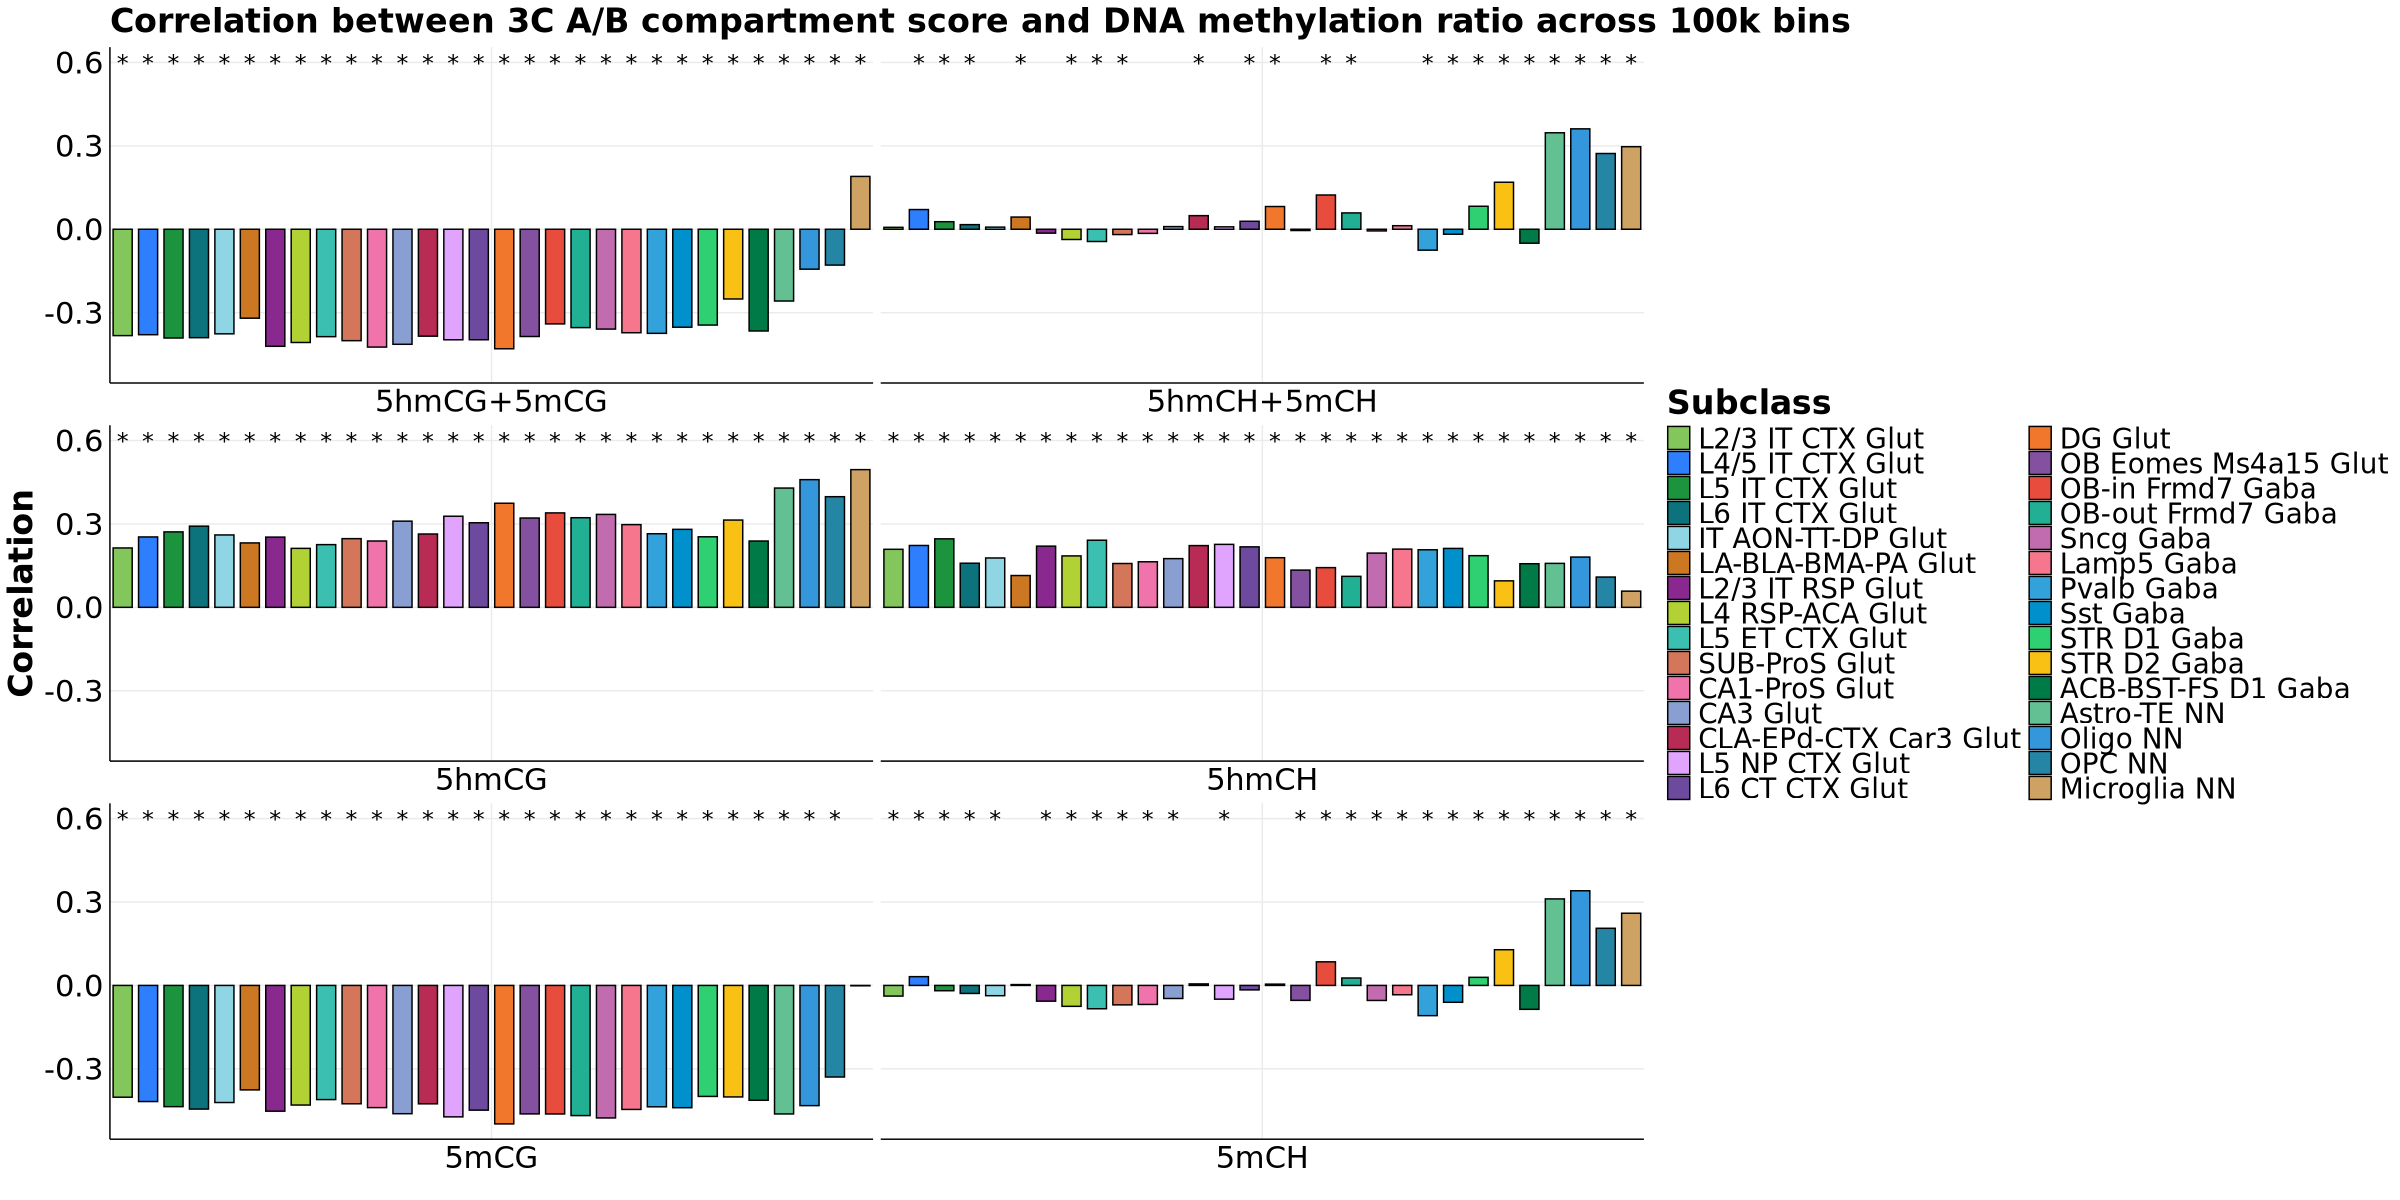

In [56]:
options(repr.plot.width = 24, repr.plot.height = 12, repr.plot.res = 100)
ggplot(all_correlations, aes(x = Group, y = correlation, fill = subclass)) +
  geom_bar(stat = "identity", position = position_dodge(width = 1.2), color = "black") +
  geom_text(aes(x = Group, y = 0.6, label = significance, group = subclass), 
            position = position_dodge(width = 1.2), 
            size = 6) +
  theme_minimal() +
  scale_fill_manual(values = subclassUsed.col) +
  labs(title = "Correlation between 3C A/B compartment score and DNA methylation ratio across 100k bins",
       x = "",
       y = "Correlation",
       fill = "Subclass") +
  theme(plot.title = element_text(size = 24, face = "bold"),
        axis.text.x = element_text(size = 22, color = "black"), # , angle = 45, hjust = 1
        axis.text.y = element_text(size = 22, color = "black"),
        axis.title.y = element_text(size = 24, color = "black", face = "bold"),
        legend.text = element_text(size = 20, color = "black"),
        legend.title = element_text(size = 24, face = "bold", color = "black"),
        strip.text = element_blank(),
        panel.grid.major = element_line(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(color = "black"),
        legend.position = "right") +
  facet_wrap(~ Group, scales = "free_x", nrow = 3)

In [57]:
all_correlations

subclass,correlation,p_value,Group,significance
<fct>,<dbl>,<dbl>,<fct>,<chr>
L2/3 IT CTX Glut,0.2135773,5.744489e-246,5hmCG,*
L4/5 IT CTX Glut,0.2531789,0.000000e+00,5hmCG,*
L5 IT CTX Glut,0.2713751,0.000000e+00,5hmCG,*
L6 IT CTX Glut,0.2919840,0.000000e+00,5hmCG,*
IT AON-TT-DP Glut,0.2603694,0.000000e+00,5hmCG,*
LA-BLA-BMA-PA Glut,0.2316942,2.849956e-290,5hmCG,*
L2/3 IT RSP Glut,0.2526256,0.000000e+00,5hmCG,*
L4 RSP-ACA Glut,0.2120878,1.810483e-242,5hmCG,*
L5 ET CTX Glut,0.2255689,7.505285e-275,5hmCG,*


In [58]:
all_correlations <- all_correlations %>%
  mutate(
    omics = case_when(
      Group %in% c("5hmCG", "5hmCH") ~ "5hmC",
      Group %in% c("5hmCG+5mCG", "5hmCH+5mCH") ~ "5hmC+5mC",
      Group %in% c("5mCG", "5mCH") ~ "5mC",
      TRUE ~ Group
    ),
    modification = case_when(
      Group %in% c("5hmCG", "5hmCG+5mCG", "5mCG") ~ "CG",
      Group %in% c("5hmCH", "5hmCH+5mCH", "5mCH") ~ "CH",
      TRUE ~ "Unknown"
    )
  )

In [59]:
all_correlations

subclass,correlation,p_value,Group,significance,omics,modification
<fct>,<dbl>,<dbl>,<fct>,<chr>,<chr>,<chr>
L2/3 IT CTX Glut,0.2135773,5.744489e-246,5hmCG,*,5hmC,CG
L4/5 IT CTX Glut,0.2531789,0.000000e+00,5hmCG,*,5hmC,CG
L5 IT CTX Glut,0.2713751,0.000000e+00,5hmCG,*,5hmC,CG
L6 IT CTX Glut,0.2919840,0.000000e+00,5hmCG,*,5hmC,CG
IT AON-TT-DP Glut,0.2603694,0.000000e+00,5hmCG,*,5hmC,CG
LA-BLA-BMA-PA Glut,0.2316942,2.849956e-290,5hmCG,*,5hmC,CG
L2/3 IT RSP Glut,0.2526256,0.000000e+00,5hmCG,*,5hmC,CG
L4 RSP-ACA Glut,0.2120878,1.810483e-242,5hmCG,*,5hmC,CG
L5 ET CTX Glut,0.2255689,7.505285e-275,5hmCG,*,5hmC,CG


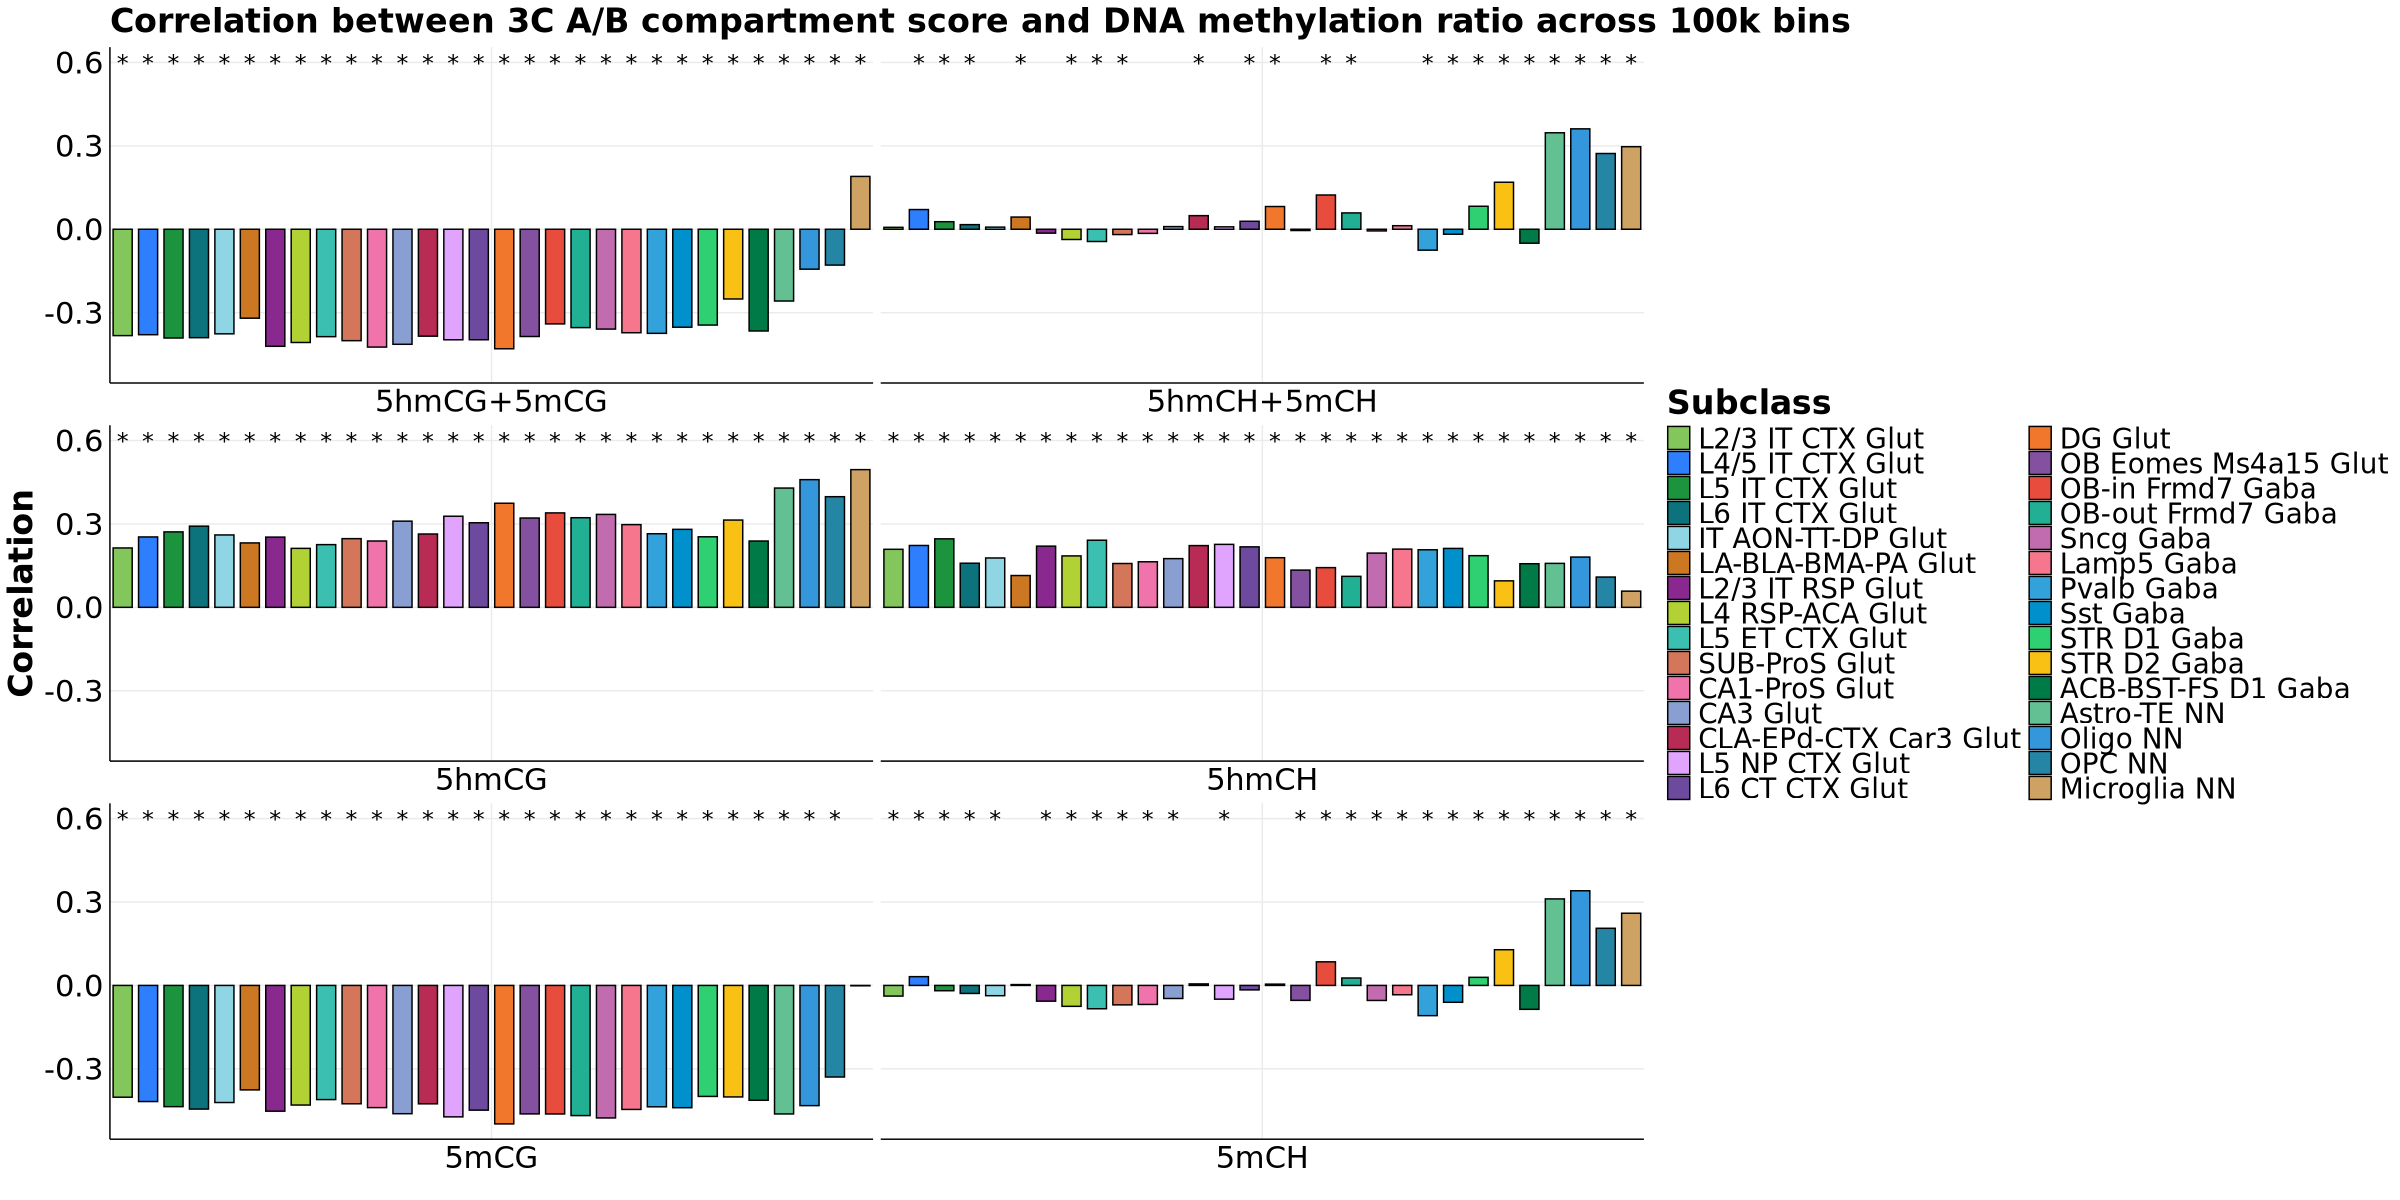

In [60]:
options(repr.plot.width = 24, repr.plot.height = 12, repr.plot.res = 100)
ggplot(all_correlations, aes(x = Group, y = correlation, fill = subclass)) +
  geom_bar(stat = "identity", position = position_dodge(width = 1.2), color = "black") +
  geom_text(aes(x = Group, y = 0.6, label = significance, group = subclass),
            position = position_dodge(width = 1.2),
            size = 6) +
  theme_minimal() +
  scale_fill_manual(values = subclassUsed.col) +
  labs(title = "Correlation between 3C A/B compartment score and DNA methylation ratio across 100k bins",
       x = "",
       y = "Correlation",
       fill = "Subclass") +
  theme(plot.title = element_text(size = 24, face = "bold"),
        axis.text.x = element_text(size = 22, color = "black"),
        axis.text.y = element_text(size = 22, color = "black"),
        axis.title.y = element_text(size = 24, color = "black", face = "bold"),
        legend.text = element_text(size = 20, color = "black"),
        legend.title = element_text(size = 24, face = "bold", color = "black"),
        strip.text = element_blank(),
        panel.grid.major = element_line(),
        panel.grid.minor = element_blank(),
        axis.line = element_line(color = "black"),
        legend.position = "right") +
  facet_wrap(~ Group, scales = "free_x", nrow = 3)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


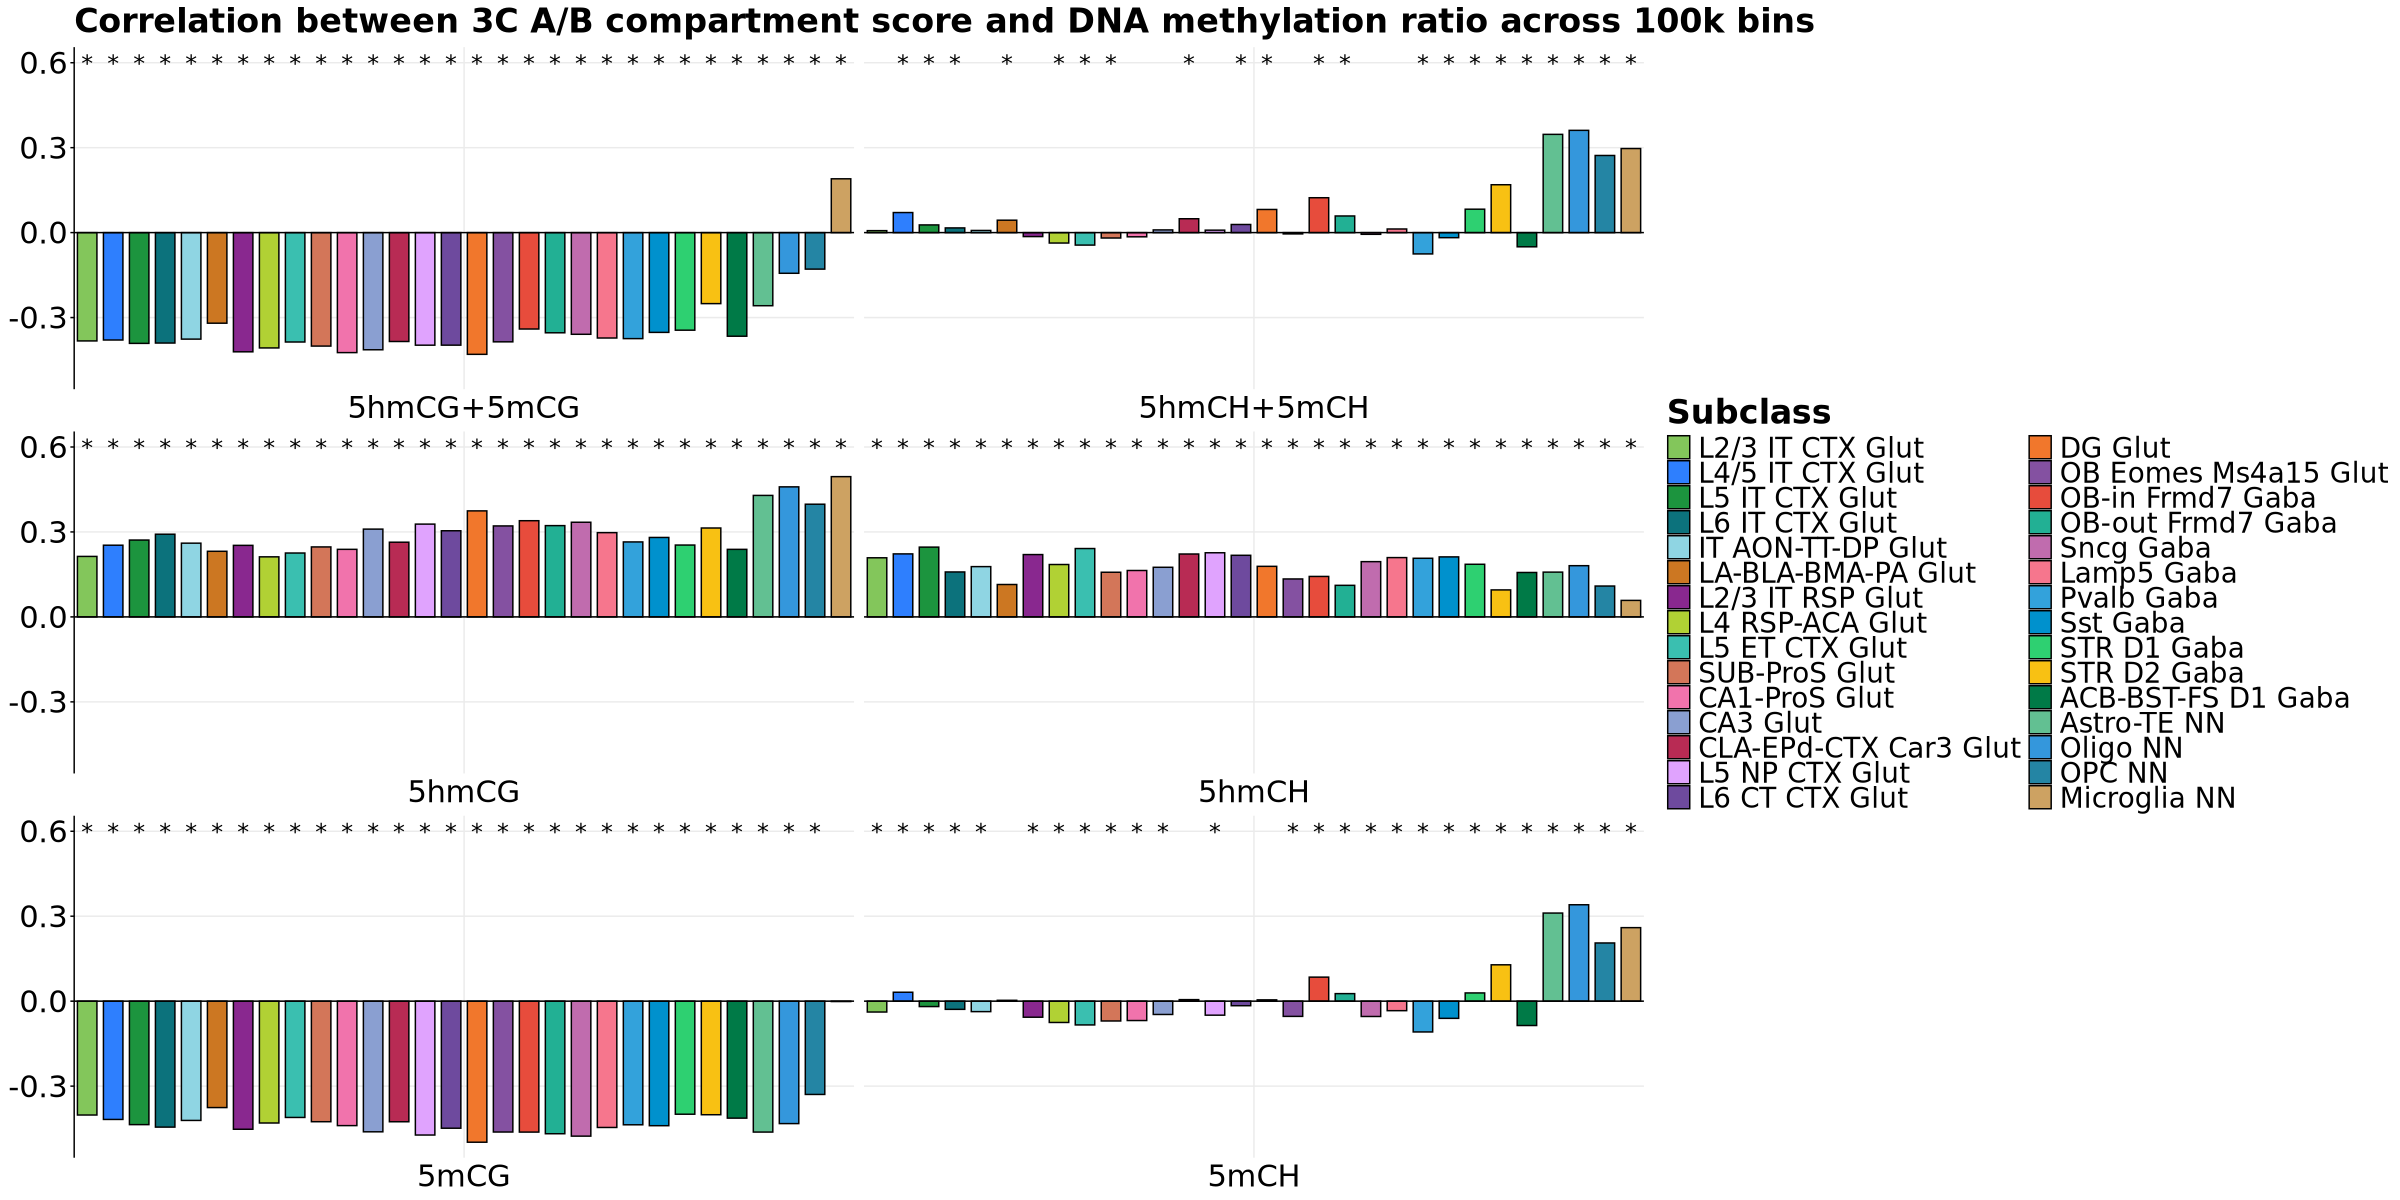

In [61]:
ggplot(all_correlations, aes(x = Group, y = correlation, fill = subclass)) +
  geom_bar(stat = "identity", position = position_dodge(width = 1.2), color = "black") +
  geom_text(aes(x = Group, y = 0.6, label = significance, group = subclass), 
            position = position_dodge(width = 1.2), 
            size = 6) +
  geom_hline(yintercept = 0, color = "black", linetype = "solid", size = 0.5) +
  theme_minimal() +
  scale_fill_manual(values = subclassUsed.col) +
  labs(title = "Correlation between 3C A/B compartment score and DNA methylation ratio across 100k bins",
       x = "",
       y = "Correlation",
       fill = "Subclass") +
  theme(
    plot.title = element_text(size = 24, face = "bold"),
    axis.text.x = element_text(size = 22, color = "black"),
    axis.text.y = element_text(size = 22, color = "black"),
    axis.title.y = element_blank(),
    axis.title.x = element_blank(),
    legend.text = element_text(size = 20, color = "black"),
    legend.title = element_text(size = 24, face = "bold", color = "black"),
    strip.text = element_blank(),
    panel.grid.major = element_line(),
    panel.grid.minor = element_blank(),
    axis.line = element_blank(),
    legend.position = "right"
  ) +
  facet_wrap(~ Group, scales = "free_x", nrow = 3) +
  theme(
    strip.text = element_blank(),
    axis.text.y = element_text(size = 22, color = "black"),
    axis.ticks.y = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    panel.spacing.x = unit(0.5, "lines")
  )

In [62]:
pdf("../output/10-Pearson_Correlation_between_DNA_Methylation_Ratio_and_3C_AB_Compartment_Score_barplot_including_sig_20251030.pdf",width = 24,height = 12)
ggplot(all_correlations, aes(x = Group, y = correlation, fill = subclass)) +
  geom_bar(stat = "identity", position = position_dodge(width = 1.2), color = "black") +
  geom_text(aes(x = Group, y = 0.6, label = significance, group = subclass), 
            position = position_dodge(width = 1.2), 
            size = 6) +
  geom_hline(yintercept = 0, color = "black", linetype = "solid", size = 0.5) +
  theme_minimal() +
  scale_fill_manual(values = subclassUsed.col) +
  labs(title = "Correlation between 3C A/B compartment score and DNA methylation ratio across 100k bins",
       x = "",
       y = "Correlation",
       fill = "Subclass") +
  theme(
    plot.title = element_text(size = 24, face = "bold"),
    axis.text.x = element_text(size = 22, color = "black"),
    axis.text.y = element_text(size = 22, color = "black"),
    axis.title.y = element_blank(),
    axis.title.x = element_blank(),
    legend.text = element_text(size = 20, color = "black"),
    legend.title = element_text(size = 24, face = "bold", color = "black"),
    strip.text = element_blank(),
    panel.grid.major = element_line(),
    panel.grid.minor = element_blank(),
    axis.line = element_blank(),
    legend.position = "right"
  ) +
  facet_wrap(~ Group, scales = "free_x", nrow = 3) +
  theme(
    strip.text = element_blank(),
    axis.text.y = element_text(size = 22, color = "black"),
    axis.ticks.y = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    panel.spacing.x = unit(0.5, "lines")
  )
dev.off()

png 
  2